# Intrinsic Alignement Self-Calibration

### Import needed pkgs

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [3]:
import treecorr
from astropy.table import Table

In [4]:
import healpy as hp

In [5]:
import pyccl as ccl

In [6]:
cosmo_ccl = ccl.Cosmology(Omega_c=0.2665, Omega_b=0.05, h=0.6774, sigma8=0.817, n_s=0.96, w0=-1.0)

In [7]:
catname_list = [
    'tomo_0.1-0.4',
    'tomo_0.4-0.6',
    'tomo_0.6-0.8',
    'tomo_0.8-1.0',
    'tomo_1.0-1.3',
    'tomo_1.3-1.6',
    'tomo_1.6-3.2'
]
len(catname_list)

7

### $n(z)$ information

In [8]:
import scipy

In [9]:
file = np.load("data/nofzs/nofz_back.npz")
zB = file['z']
nzs = file['nz']

In [10]:
nz_interp_dict = {}
for i in range(7):
    inz_interp = scipy.interpolate.interp1d(zB, nzs[i], kind='linear', fill_value=0, bounds_error=False)
    nz_interp_dict[catname_list[i]] = inz_interp

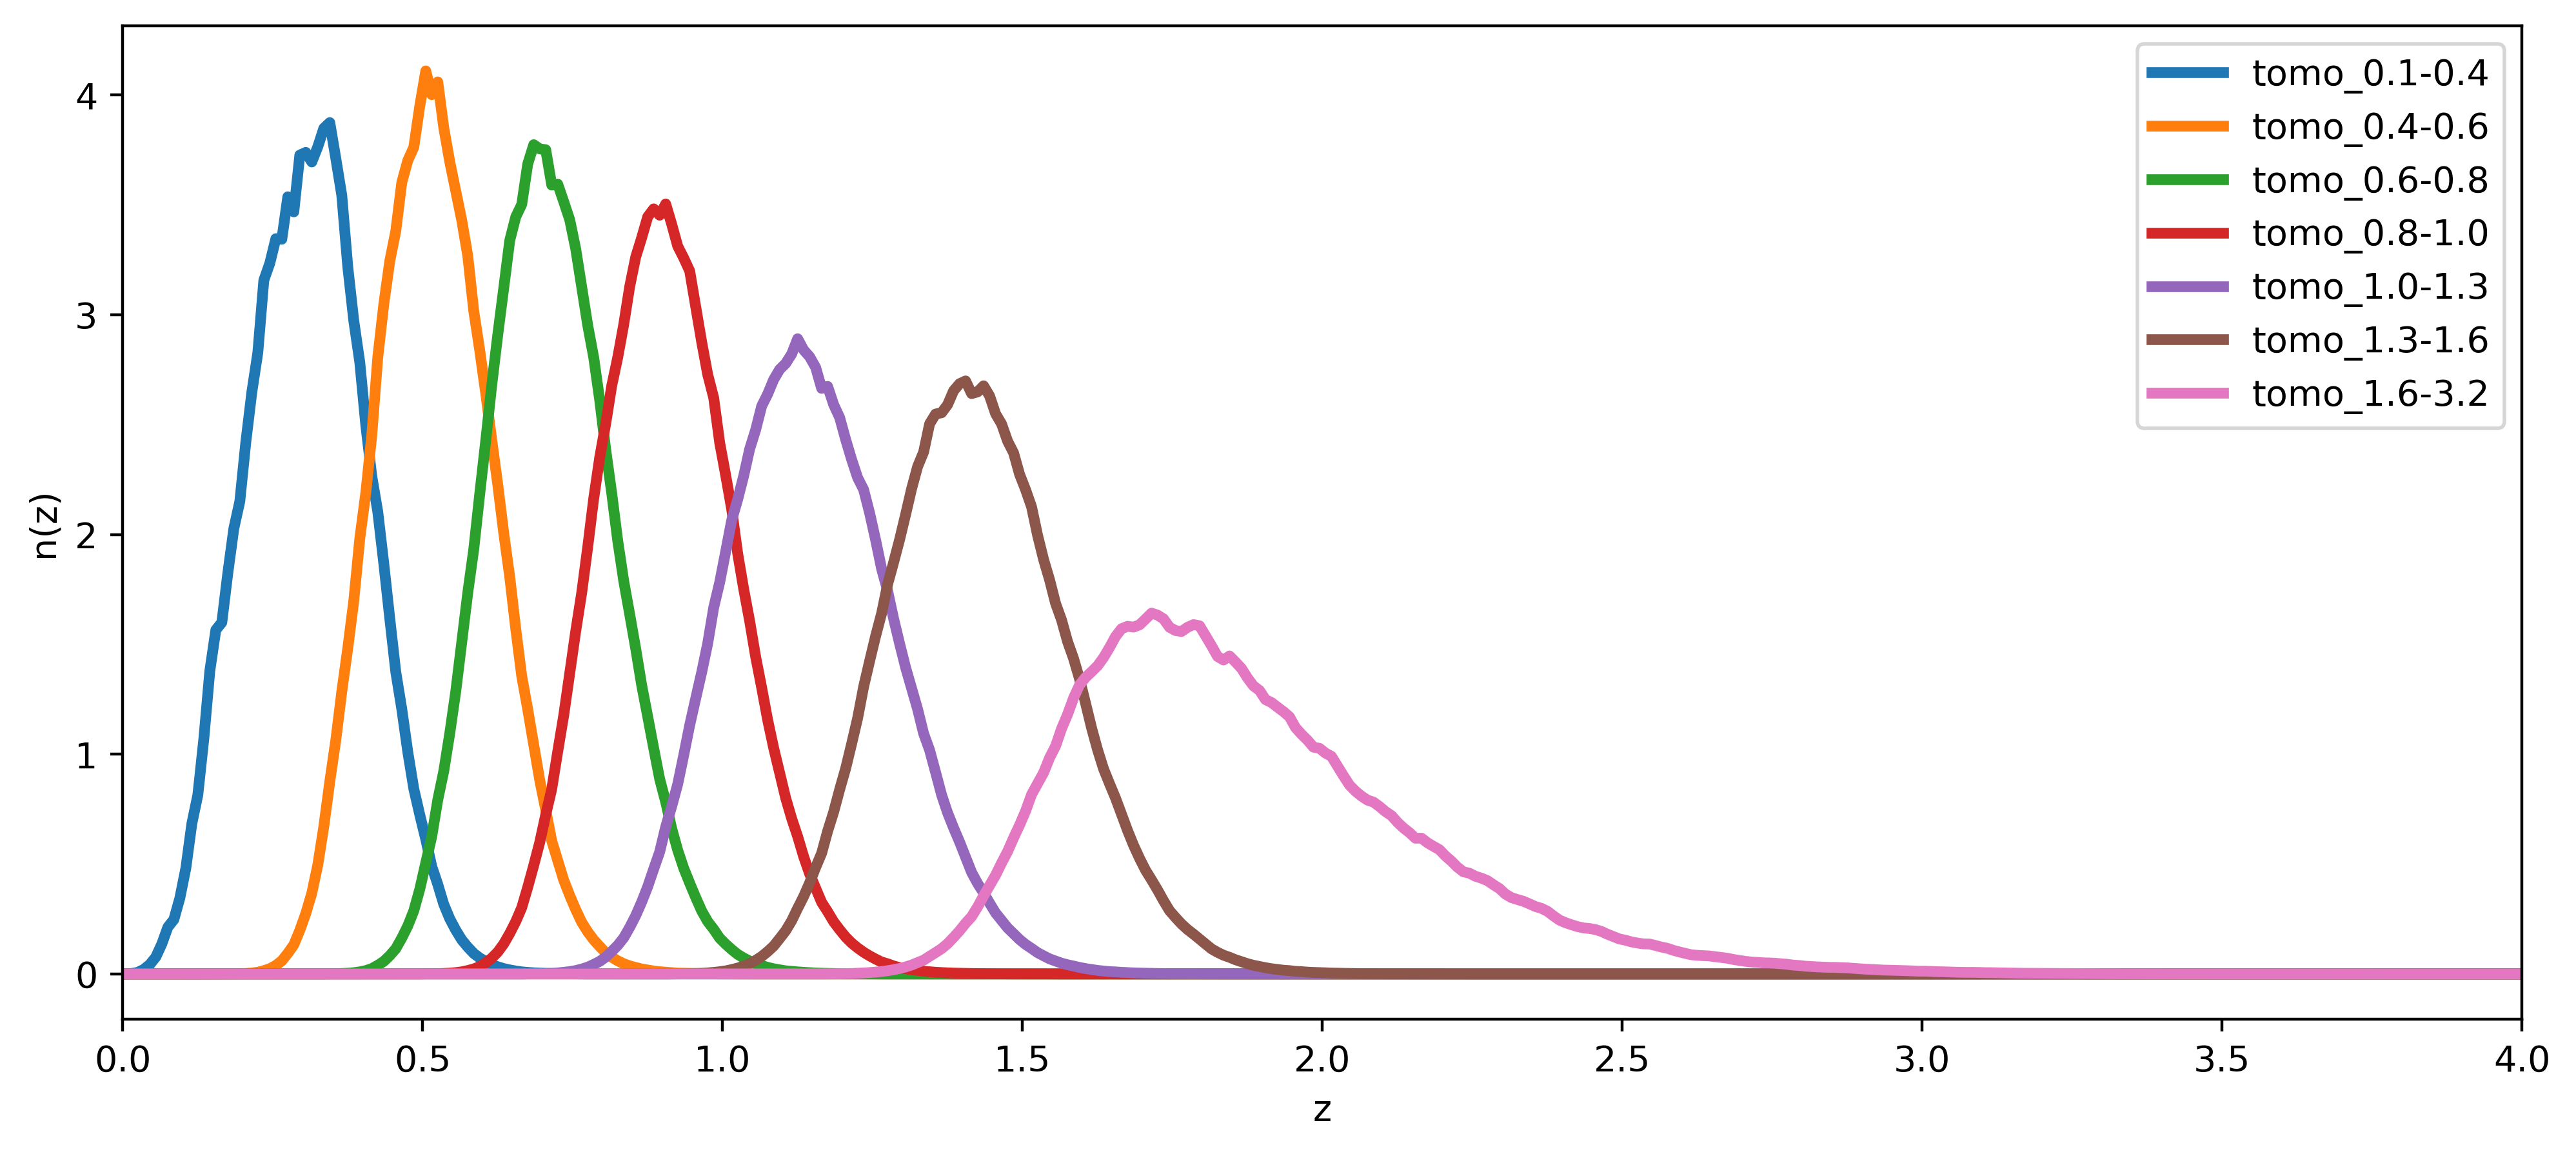

In [11]:
fig = plt.figure(figsize=(12,5), dpi=400)
for i, bin_name in enumerate(nz_interp_dict.keys()):
    plt.plot(zB, nzs[i], lw=3, label=bin_name)
plt.xlim(0,4)
plt.xlabel('z')
plt.ylabel('n(z)')
plt.legend();

In [12]:
file = np.load("data/nofzs/tomo_nz_hist2D.npz")
zp_edges = file['zp_edges']
z_edges = file['z_edges']
hist_zp_z = file['hist_zp_z']
hist_zp_z = hist_zp_z.T # H(i,j) = H(zpbin_i, zbin_j)
hist_zp_z_norm = hist_zp_z / (np.sum(hist_zp_z)*0.01**2)

In [13]:
zp_ctrs = 0.5*(zp_edges[1:] + zp_edges[:-1])
z_ctrs = 0.5*(z_edges[1:] + z_edges[:-1])

In [14]:
hist_zp_z.shape, zp_edges.shape

((400, 400), (401,))

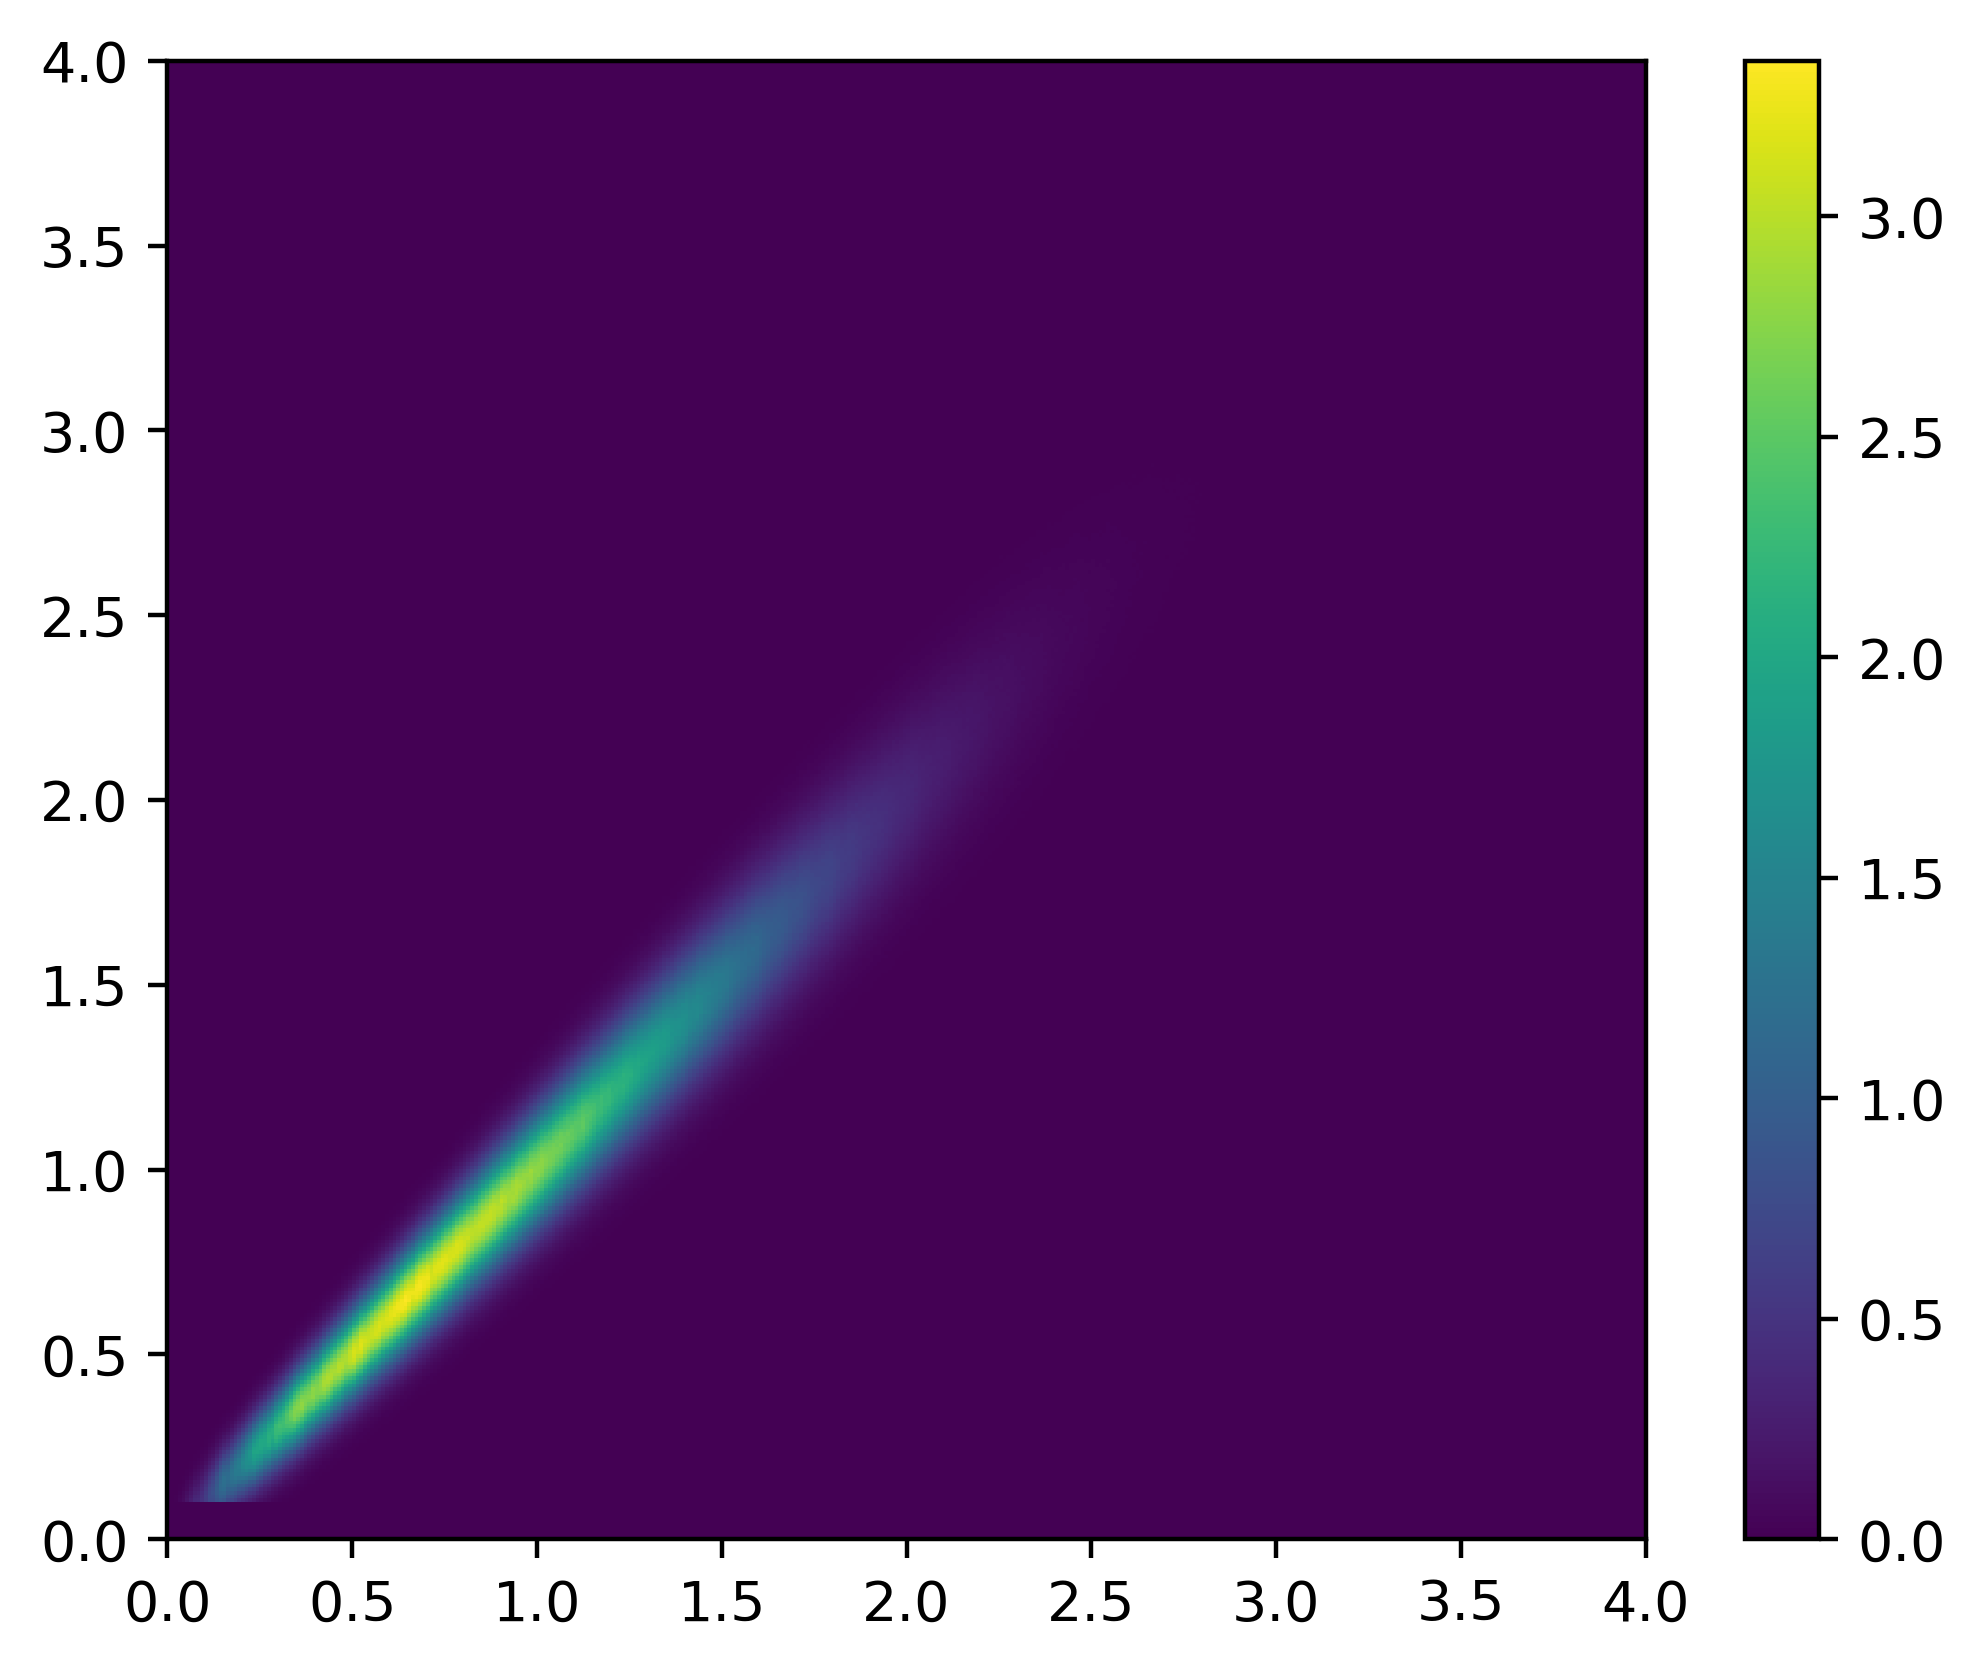

In [15]:
plt.figure(dpi=400)
plt.imshow(hist_zp_z_norm, origin='lower', extent=(zp_edges[0], zp_edges[-1], z_edges[0], z_edges[-1]))
# plt.imshow(hist_zp_z_norm, origin='lower')
plt.colorbar();

In [16]:
p_z_zph_interp = scipy.interpolate.RegularGridInterpolator((zp_ctrs, z_ctrs), hist_zp_z_norm, bounds_error=False, fill_value=None)

### Load from file

In [17]:
import pickle

In [18]:
zp_min = 1.3
zp_max = 1.6

In [19]:
catname = f"tomo_{zp_min:.1f}-{zp_max:.1f}"
catname

'tomo_1.3-1.6'

In [20]:
nz_interp_func = nz_interp_dict[catname]

In [21]:
with open(f"results/corr_funcs/{catname}.pkl", "rb") as f:
    ng_corr = pickle.load(f)

In [22]:
with open(f"results/corr_funcs/{catname}_S.pkl", "rb") as f:
    ng_S_corr = pickle.load(f)

In [23]:
with open(f"results/corr_funcs/{catname}_r.pkl", "rb") as f:
    rg_corr = pickle.load(f)

Text(0, 0.5, '$w(\\theta)$')

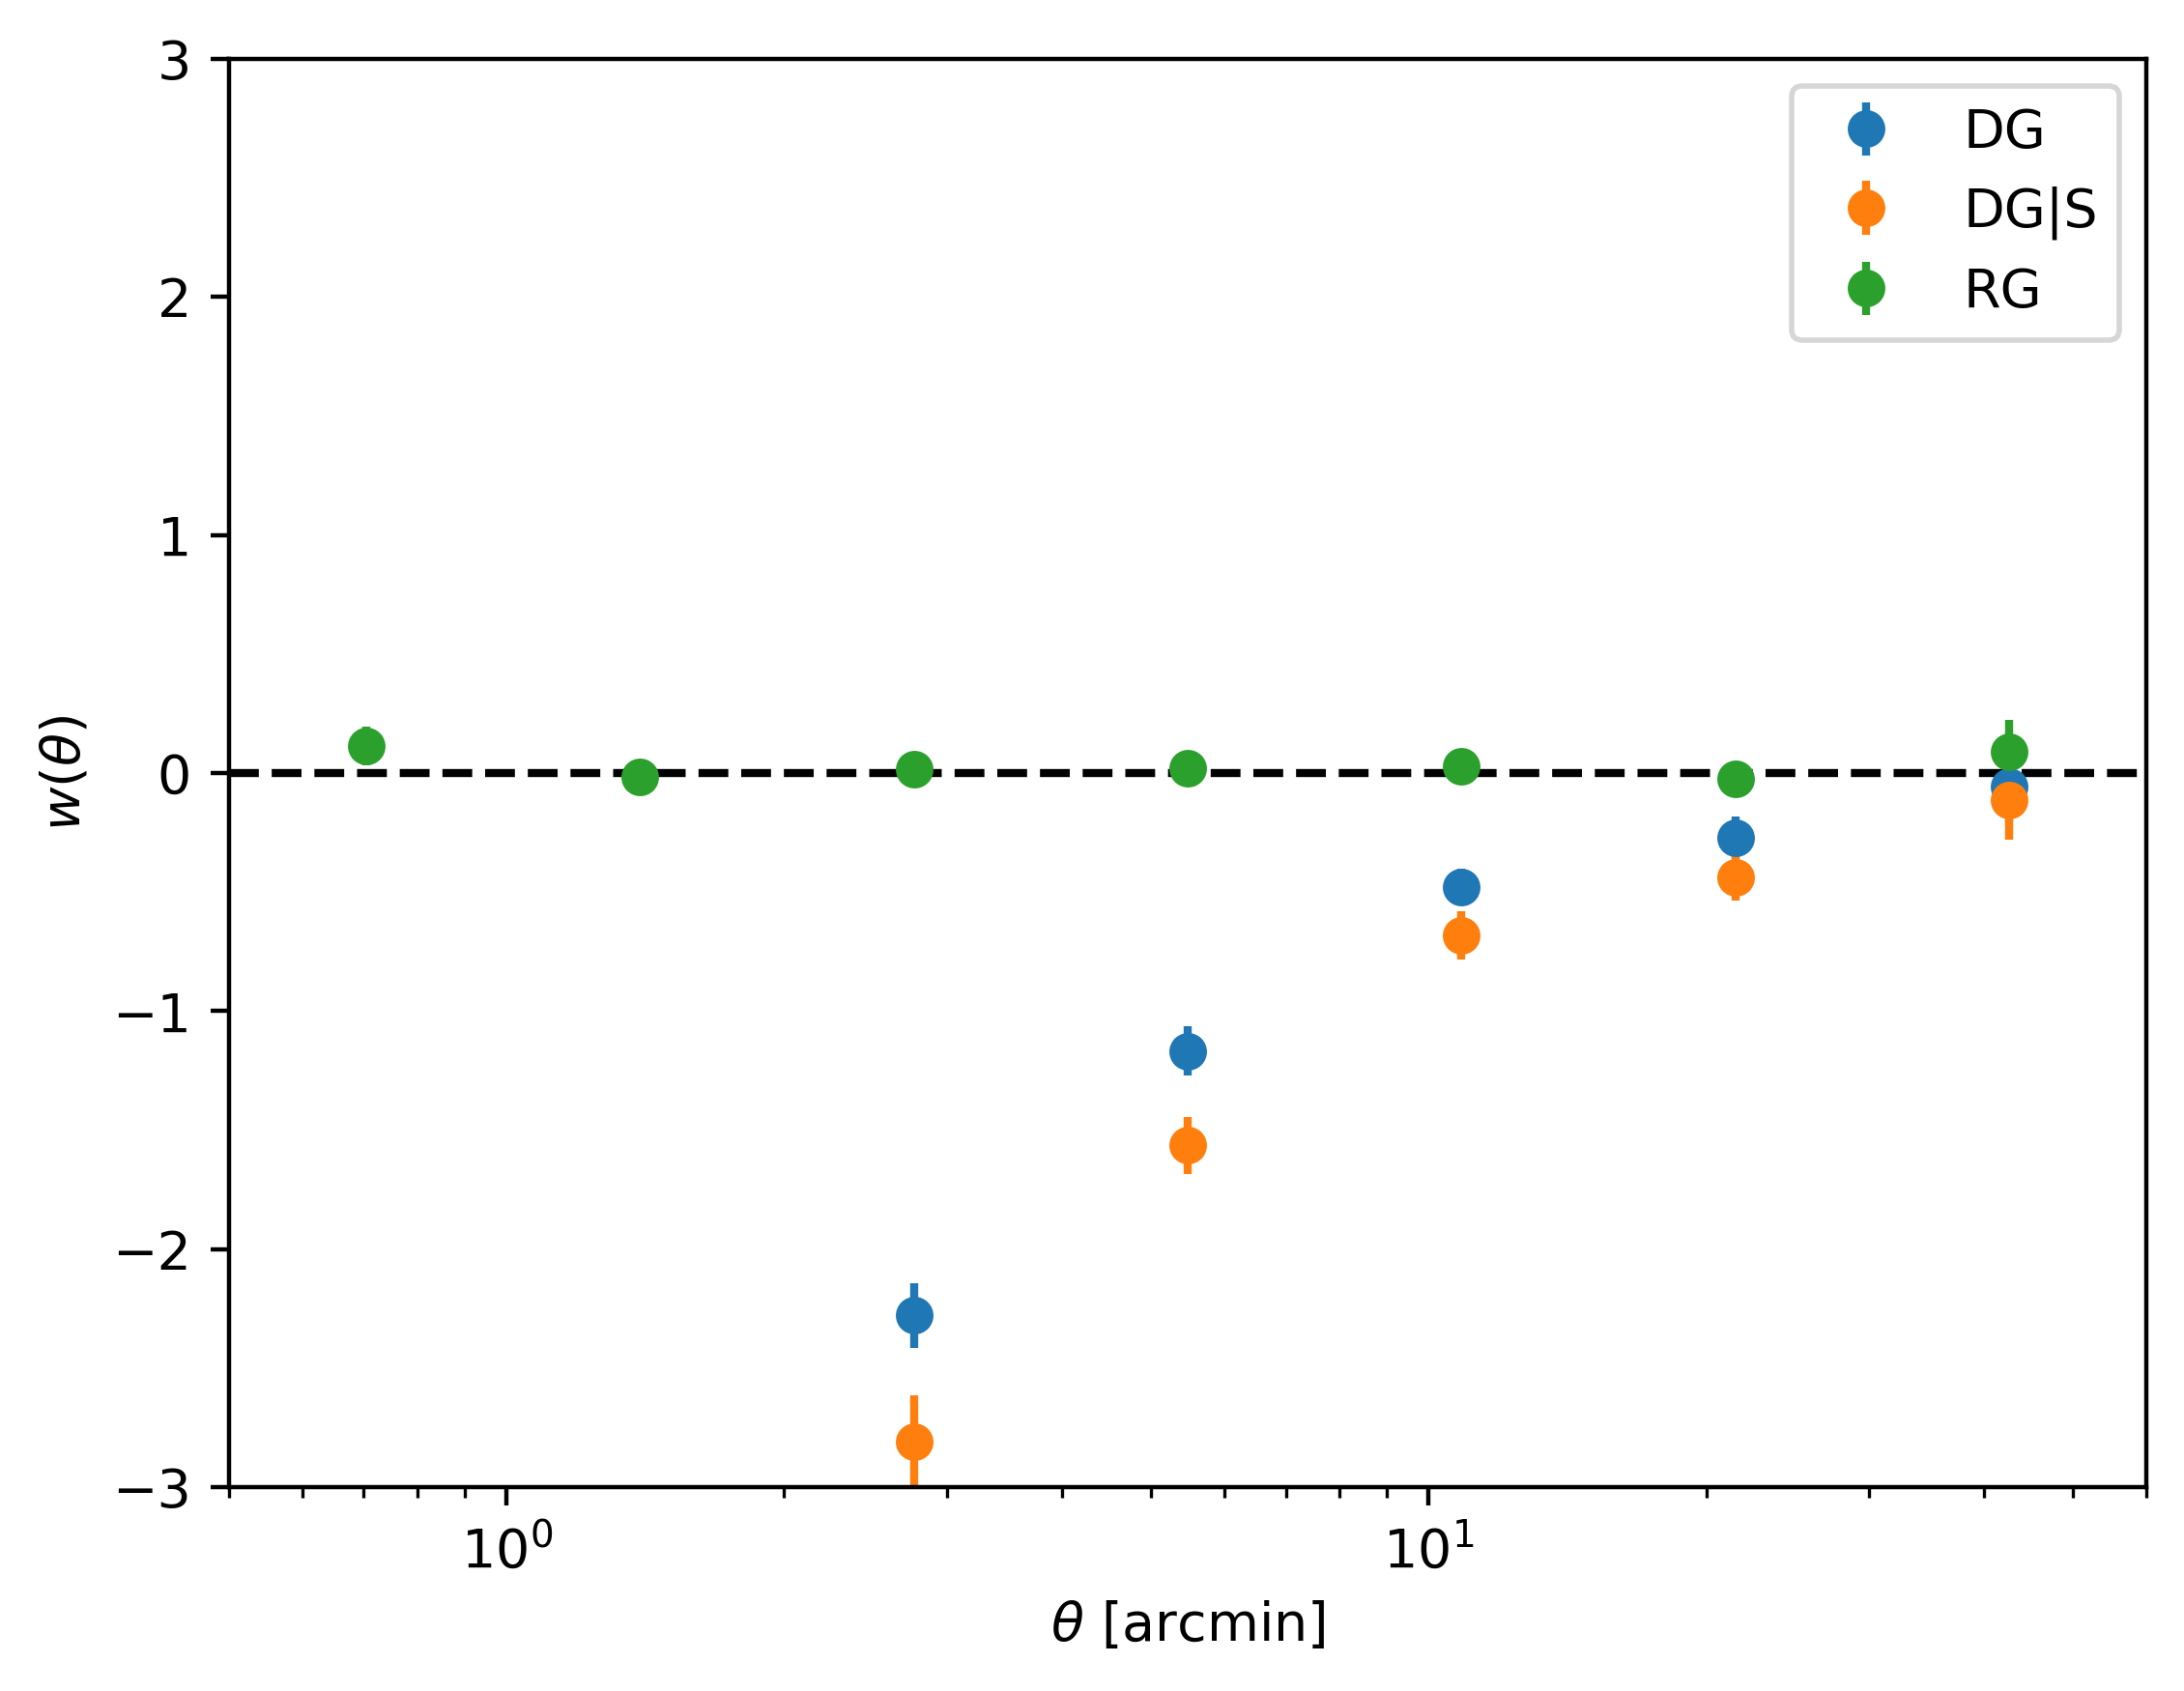

In [24]:
plt.figure(dpi=400)
# plt.errorbar(rg_corr.rnom*0.95, ng_corr.raw_xi*1e4, np.sqrt(ng_corr.raw_varxi)*1e4, fmt='o', label='DG')
plt.errorbar(rg_corr.rnom, ng_corr.xi*1e4, np.sqrt(ng_corr.varxi)*1e4, fmt='o', label='DG')
plt.errorbar(rg_corr.rnom, ng_S_corr.xi*1e4, np.sqrt(ng_S_corr.varxi)*1e4, fmt='o', label='DG|S')
plt.errorbar(rg_corr.rnom, rg_corr.xi*1e4, np.sqrt(rg_corr.varxi)*1e4, fmt='o', label='RG')
# plt.errorbar(ng_S_corr.rnom, ng_S_corr.xi*1e4, np.sqrt(ng_S_corr.varxi)*1e4, fmt='o')
# plt.errorbar(theta_bin, gammat, gammat_err, fmt='ok')
plt.axhline(0, c='k', ls='--')
plt.legend()
plt.semilogx()
plt.ylim(-3, 3)
plt.xlim(0.5, 60)
plt.xlabel(r'$\theta~[\rm arcmin]$')
plt.ylabel(r'$w(\theta)$')

### $Q(\ell)$ calculation

\begin{equation}
    \int\mathrm{d}z_G^P\int\mathrm{d}z_g^P\int\mathrm{d}z_G W_L(z_L, z_G)p(z_G|z_G^P)p(z_g|z_g^P)p(z_g|z_g^P)S(z_G^P,z_g^P)n_i^P(z_G^P)n_i^P(z_g^P)
\end{equation}

In [25]:
sol = 2.99792458*1e5

In [26]:
## W_L
## z_S is z_G
def W_L(z_L, z_S, cosmo:ccl.Cosmology):
    chi_L = ccl.comoving_angular_distance(cosmo=cosmo, a=1./(1+z_L)) # Mpc
    chi_S = ccl.comoving_angular_distance(cosmo=cosmo, a=1./(1+z_S)) # Mpc
    OmegaM = cosmo.omega_x(a=1.0, species='matter')
    return (1.5*OmegaM*(cosmo_ccl["h"]*100)**2/sol**2 * (1 + z_L)*chi_L*(1 - chi_L/chi_S))*np.heaviside(z_S-z_L, 0)

In [27]:
import functools

In [28]:
W_L_partial = functools.partial(W_L, cosmo=cosmo_ccl)

In [29]:
def K_kernel(z_G, z_g, zp_G, zp_g, p_z_zph_func, nz_func):
    K_val = p_z_zph_func((zp_G, z_G)) * p_z_zph_func((zp_g, z_g)) * nz_func(zp_G) * nz_func(zp_g)
    return K_val

In [30]:
K_kernel_partial = functools.partial(K_kernel, p_z_zph_func=p_z_zph_interp, nz_func=nz_interp_func)

In [31]:
from joblib import Parallel, delayed

In [32]:
z_L_rng = np.linspace(1e-5, 4.0, 256)
zp_G_rng = np.linspace(zp_min, zp_max, 1000)
zp_g_rng = np.linspace(zp_min, zp_max, 1000)
z_G_rng = np.linspace(1e-5, 4, 1000)

p_z_zph_zp_zG_grid = p_z_zph_interp(
    np.stack(
        np.meshgrid(zp_G_rng, z_G_rng, indexing='ij'),
        axis=-1
    )
)
p_z_zph_zpg_zL_grid = p_z_zph_interp(
    np.stack(
        np.meshgrid(zp_g_rng, z_L_rng, indexing='ij'),
        axis=-1
    )
)

A_int = np.empty((z_L_rng.shape[0], zp_G_rng.shape[0])) ## (z_L, zp_G)
B_int = np.empty((z_L_rng.shape[0], zp_G_rng.shape[0])) ## (z_L, zp_G)
eta_Gg = np.empty(z_L_rng.shape[0])
eta_Ig = np.empty(z_L_rng.shape[0])
nz_zp_G = nz_interp_func(zp_G_rng)
nz_zp_g = nz_interp_func(zp_g_rng)

In [33]:
def compute_eta_Gg_for_z_L(i, z_L):
    A_row = np.empty(zp_G_rng.shape[0])
    B_row = np.empty(zp_G_rng.shape[0])
    C_row = np.empty(zp_G_rng.shape[0])
    W_L_zG = W_L_partial(z_L, z_G_rng)
    p_z_zph_zpg_zL = p_z_zph_zpg_zL_grid[:, i]

    for j, zp_G in enumerate(zp_G_rng):
        A_row[j] = scipy.integrate.simpson(
            W_L_zG * p_z_zph_zp_zG_grid[j, :],
            x=z_G_rng
        )

        B_row[j] = scipy.integrate.simpson(
            p_z_zph_zpg_zL * nz_zp_g * np.heaviside(zp_g_rng - zp_G, 0),
            x=zp_g_rng
        )

        C_row[j] = scipy.integrate.simpson(
            p_z_zph_zpg_zL * nz_zp_g,
            x=zp_g_rng
        )

    eta_val_nom = 2*scipy.integrate.simpson(
        nz_zp_G * A_row * B_row,
        x=zp_G_rng
    )
    eta_val_denom = scipy.integrate.simpson(
        nz_zp_G * A_row * C_row,
        x=zp_G_rng
    )
    eta_val = np.divide(eta_val_nom, eta_val_denom, out=np.zeros_like(eta_val_nom), where=(eta_val_denom != 0))
    return i, eta_val

def compute_eta_Ig_for_z_L(i, z_L):
    A_row = np.empty(zp_G_rng.shape[0])
    B_row = np.empty(zp_G_rng.shape[0])
    C_row = np.empty(zp_G_rng.shape[0])
    p_z_zph_zpg_zL = p_z_zph_zpg_zL_grid[:, i]

    for j, zp_G in enumerate(zp_G_rng):
        A_row[j] = scipy.integrate.simpson(
            p_z_zph_zp_zG_grid[j, :],
            x=z_G_rng
        )

        B_row[j] = scipy.integrate.simpson(
            p_z_zph_zpg_zL * nz_zp_g * np.heaviside(zp_g_rng - zp_G, 0),
            x=zp_g_rng
        )

        C_row[j] = scipy.integrate.simpson(
            p_z_zph_zpg_zL * nz_zp_g,
            x=zp_g_rng
        )

    eta_val_nom = 2*scipy.integrate.simpson(
        nz_zp_G * A_row * B_row,
        x=zp_G_rng
    )
    eta_val_denom = scipy.integrate.simpson(
        nz_zp_G * A_row * C_row,
        x=zp_G_rng
    )
    eta_val = np.divide(eta_val_nom, eta_val_denom, out=np.zeros_like(eta_val_nom), where=(eta_val_denom != 0))
    return i, eta_val

In [34]:
%%time
results = Parallel(n_jobs=16)(
    delayed(compute_eta_Gg_for_z_L)(i, z_L)
    for i, z_L in enumerate(z_L_rng)
)

for i, eta_val in results:
    eta_Gg[i] = eta_val

CPU times: user 519 ms, sys: 188 ms, total: 707 ms
Wall time: 7.21 s


In [35]:
%%time
results = Parallel(n_jobs=16)(
    delayed(compute_eta_Ig_for_z_L)(i, z_L)
    for i, z_L in enumerate(z_L_rng)
)

for i,eta_val in results:
    eta_Ig[i] = eta_val

CPU times: user 209 ms, sys: 39.8 ms, total: 249 ms
Wall time: 3.4 s


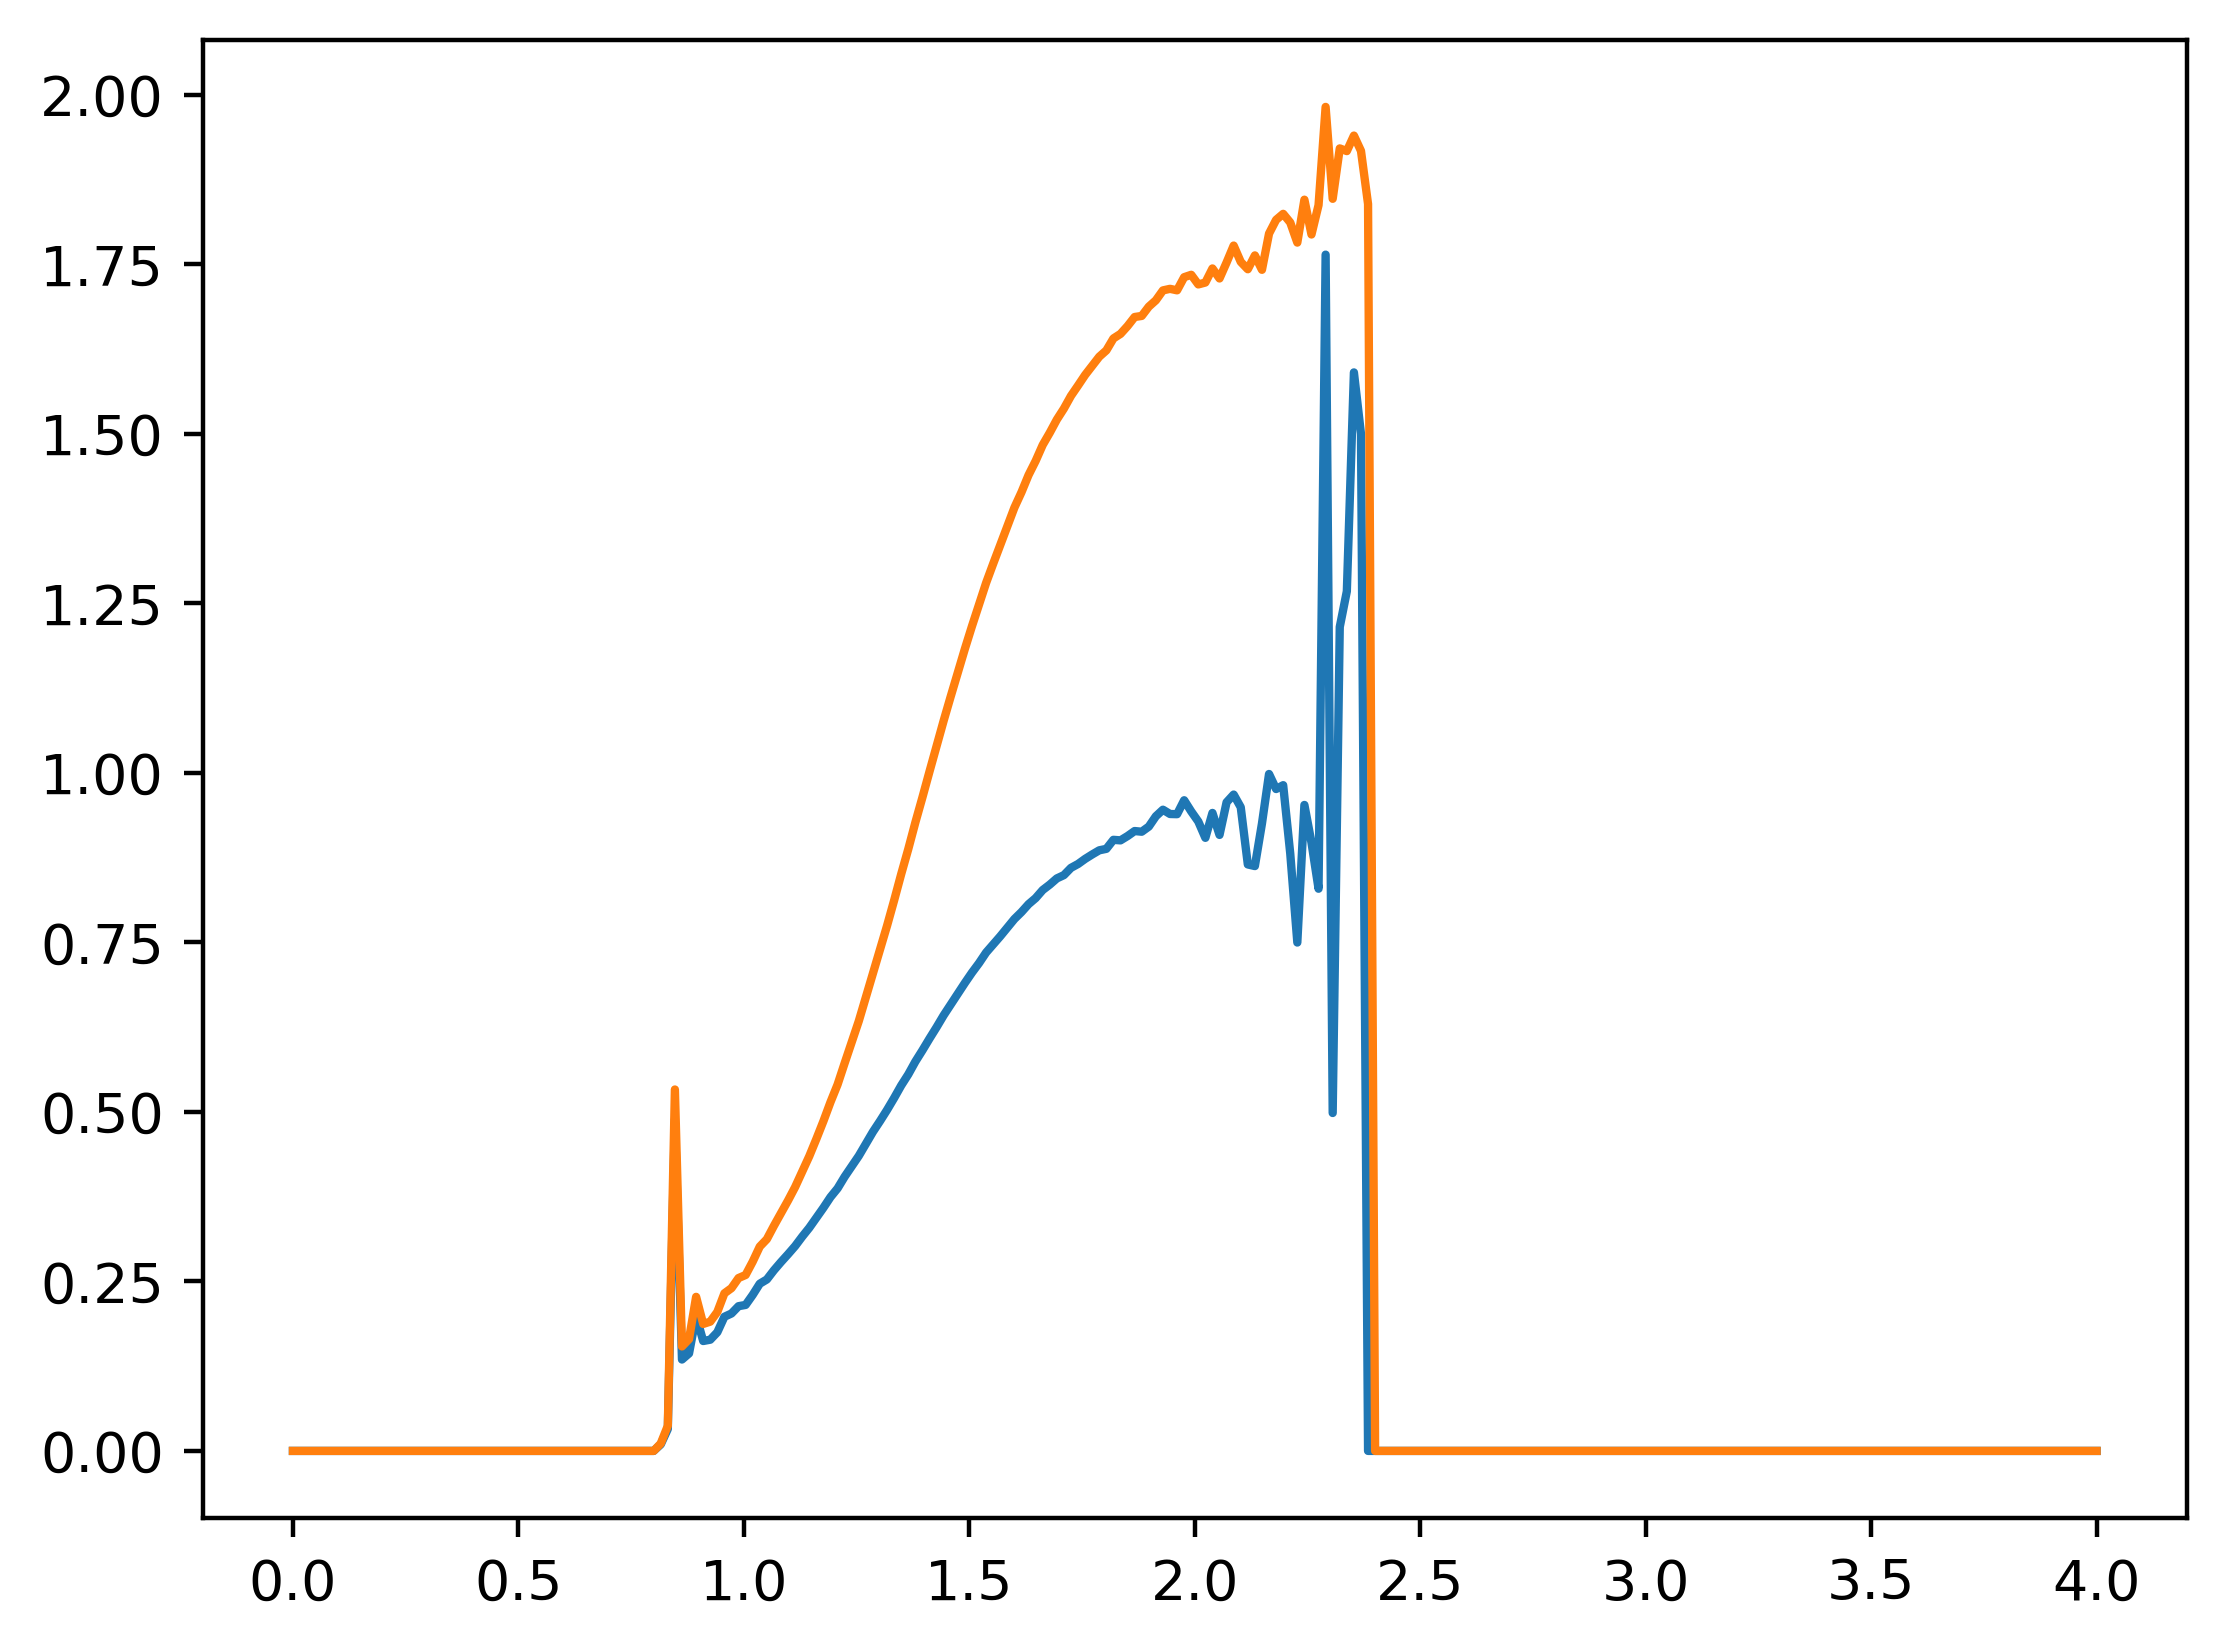

In [36]:
plt.figure(dpi=400)
plt.plot(z_L_rng, eta_Gg)
plt.plot(z_L_rng, eta_Ig)

In [37]:
wl = ccl.WeakLensingTracer(cosmo=cosmo_ccl, dndz=(z_L_rng, nz_interp_func(z_L_rng)))
nc = ccl.NumberCountsTracer(cosmo=cosmo_ccl, dndz=(z_L_rng, nz_interp_func(z_L_rng)), bias=(z_L_rng, np.ones_like(z_L_rng)), has_rsd=False)
nc_etaGg = ccl.NumberCountsTracer(cosmo=cosmo_ccl, dndz=(z_L_rng, nz_interp_func(z_L_rng)), bias=(z_L_rng, np.ones_like(z_L_rng)*eta_Gg), has_rsd=False)
nc_etaIg = ccl.NumberCountsTracer(cosmo=cosmo_ccl, dndz=(z_L_rng, nz_interp_func(z_L_rng)), bias=(z_L_rng, np.ones_like(z_L_rng)*eta_Ig), has_rsd=False)

In [38]:
def NLA_model(z, A_IA, cosmo):
    C1 = 5e-14
    rhoc0 = 2.7750 * 1e11
    OmegaM = cosmo.omega_x(a=1.0, species='matter')
    Da = ccl.growth_factor(a=1./(1+z), cosmo=cosmo)
    return -A_IA * C1 * rhoc0 * OmegaM / Da

In [39]:
nc_IA = ccl.NumberCountsTracer(cosmo=cosmo_ccl, dndz=(z_L_rng, nz_interp_func(z_L_rng)), bias=(z_L_rng, NLA_model(z_L_rng, A_IA=1.0, cosmo=cosmo_ccl)), has_rsd=False)

In [40]:
ell = np.geomspace(1.001, 1e4, 256)

In [41]:
C_Gg = ccl.angular_cl(cosmo=cosmo_ccl, tracer1=nc, tracer2=wl, ell=ell)
C_Ig = ccl.angular_cl(cosmo=cosmo_ccl, tracer1=nc, tracer2=nc_IA, ell=ell)

In [42]:
C_Gg_Select = ccl.angular_cl(cosmo=cosmo_ccl, tracer1=nc_etaGg, tracer2=wl, ell=ell)
C_Ig_Select = ccl.angular_cl(cosmo=cosmo_ccl, tracer1=nc_etaIg, tracer2=nc_IA, ell=ell)

In [43]:
theta_show = np.geomspace(0.1, 60, 100) # arcmin
theta_show_deg = theta_show/60 #deg

In [44]:
w_Gg = ccl.correlation(cosmo=cosmo_ccl, ell=ell, C_ell=C_Gg, theta=theta_show_deg, type='NG')
w_Ig = ccl.correlation(cosmo=cosmo_ccl, ell=ell, C_ell=C_Ig, theta=theta_show_deg, type='NG')
w_Gg_Select = ccl.correlation(cosmo=cosmo_ccl, ell=ell, C_ell=C_Gg_Select, theta=theta_show_deg, type='NG')
w_Ig_Select = ccl.correlation(cosmo=cosmo_ccl, ell=ell, C_ell=C_Ig_Select, theta=theta_show_deg, type='NG')

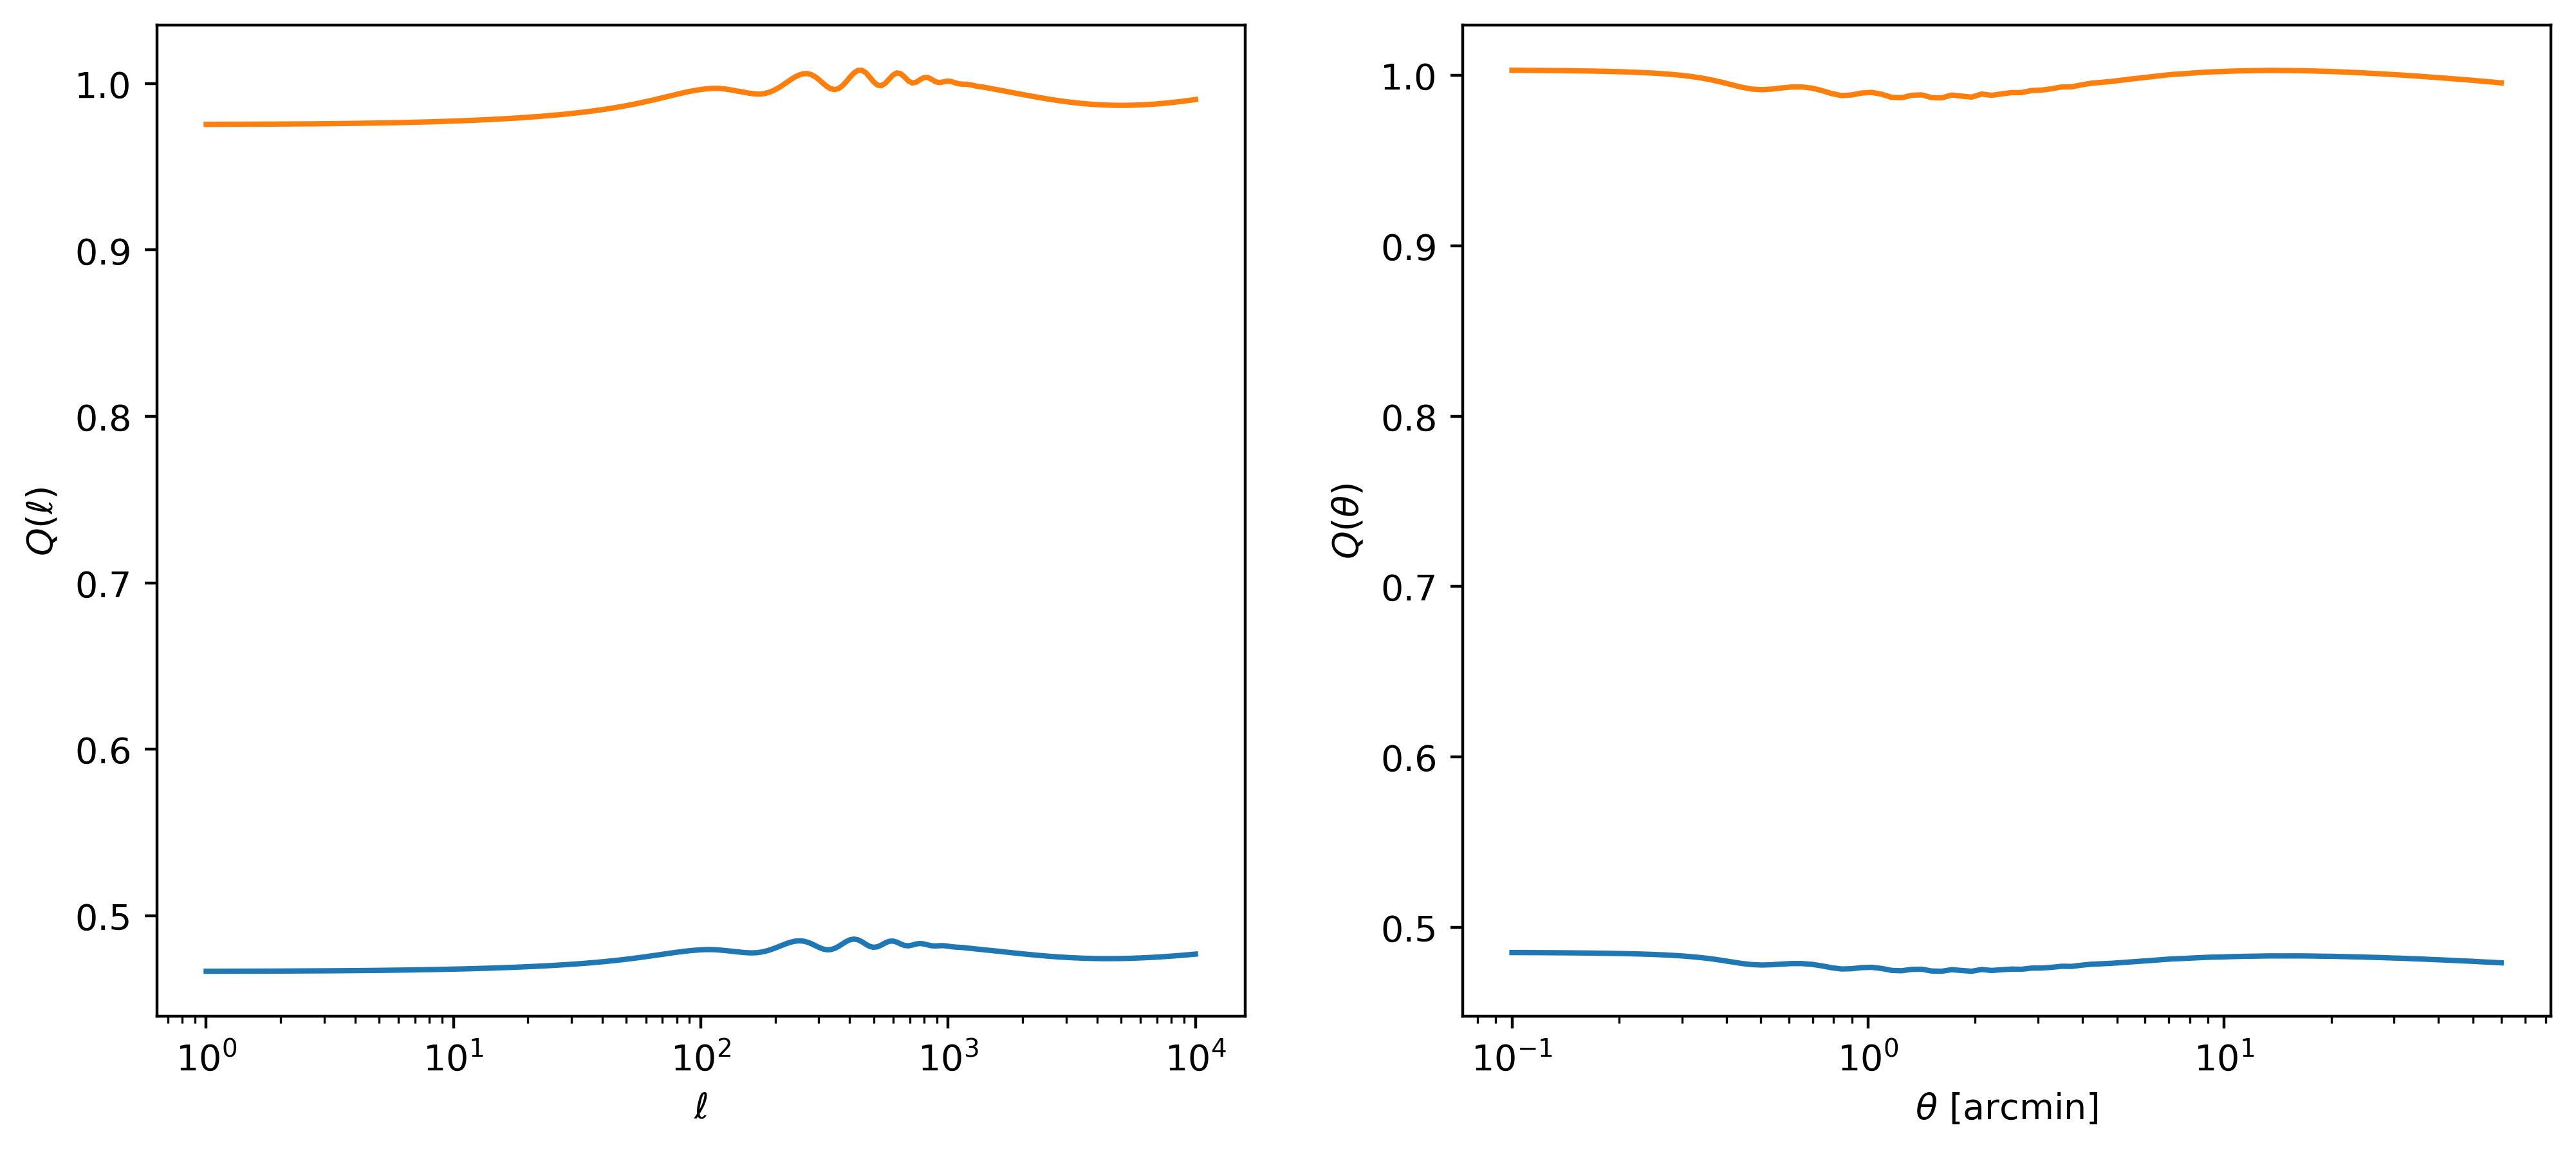

In [45]:
fig = plt.figure(figsize=(12,5), dpi=400)
ax = fig.add_subplot(121)
ax.semilogx(ell, C_Gg_Select/C_Gg)
ax.semilogx(ell, C_Ig_Select/C_Ig)
ax.set_ylabel(r'$Q(\ell)$')
ax.set_xlabel(r'$\ell$');
ax = fig.add_subplot(122)
ax.semilogx(theta_show, w_Gg_Select/w_Gg)
ax.semilogx(theta_show, w_Ig_Select/w_Ig)
ax.set_ylabel(r'$Q(\theta)$')
ax.set_xlabel(r'$\theta~[\rm arcmin]$');

### Self Calibration

In [46]:
theta_bin = rg_corr.rnom
theta_bin_deg = theta_bin/60.

In [47]:
w_Gg_dat = ccl.correlation(cosmo=cosmo_ccl, ell=ell, C_ell=C_Gg, theta=theta_bin_deg, type='NG')
w_Ig_dat = ccl.correlation(cosmo=cosmo_ccl, ell=ell, C_ell=C_Ig, theta=theta_bin_deg, type='NG')
w_Gg_Select_dat = ccl.correlation(cosmo=cosmo_ccl, ell=ell, C_ell=C_Gg_Select, theta=theta_bin_deg, type='NG')
w_Ig_Select_dat = ccl.correlation(cosmo=cosmo_ccl, ell=ell, C_ell=C_Ig_Select, theta=theta_bin_deg, type='NG')

In [48]:
Q_Gg_dat = w_Gg_Select_dat / w_Gg_dat
Q_Ig_dat = w_Ig_Select_dat / w_Ig_dat

In [49]:
w_gL_gamma = ng_corr.xi - rg_corr.xi
w_gL_gamma_S = ng_S_corr.xi - rg_corr.xi

In [50]:
wGg_SC = (Q_Ig_dat * w_gL_gamma - w_gL_gamma_S) / (Q_Ig_dat - Q_Gg_dat)
wIg_SC = (w_gL_gamma_S - Q_Gg_dat * w_gL_gamma) / (Q_Ig_dat - Q_Gg_dat)

In [51]:
func1 = lambda corrs: ((corrs[0].xi - corrs[2].xi) * Q_Ig_dat - (corrs[1].xi - corrs[2].xi)) / (Q_Ig_dat - Q_Gg_dat)
func2 = lambda corrs: ((corrs[1].xi - corrs[2].xi) - (corrs[0].xi - corrs[2].xi) * Q_Gg_dat) / (Q_Ig_dat - Q_Gg_dat)

In [52]:
func3 = lambda corrs: np.concatenate([((corrs[0].xi - corrs[2].xi) * Q_Ig_dat - (corrs[1].xi - corrs[2].xi)) / (Q_Ig_dat - Q_Gg_dat)] +\
                       [((corrs[1].xi - corrs[2].xi) - (corrs[0].xi - corrs[2].xi) * Q_Gg_dat) / (Q_Ig_dat - Q_Gg_dat)])

In [53]:
wGg_SC_cov = treecorr.estimate_multi_cov([ng_corr, ng_S_corr, rg_corr], method='jackknife', func=func1)
wIg_SC_cov = treecorr.estimate_multi_cov([ng_corr, ng_S_corr, rg_corr], method='jackknife', func=func2)

In [54]:
wGg_Ig_SC_X_cov = treecorr.estimate_multi_cov([ng_corr, ng_S_corr, rg_corr], method='jackknife', func=func3)

In [55]:
diag_vals = np.diag(wGg_Ig_SC_X_cov)

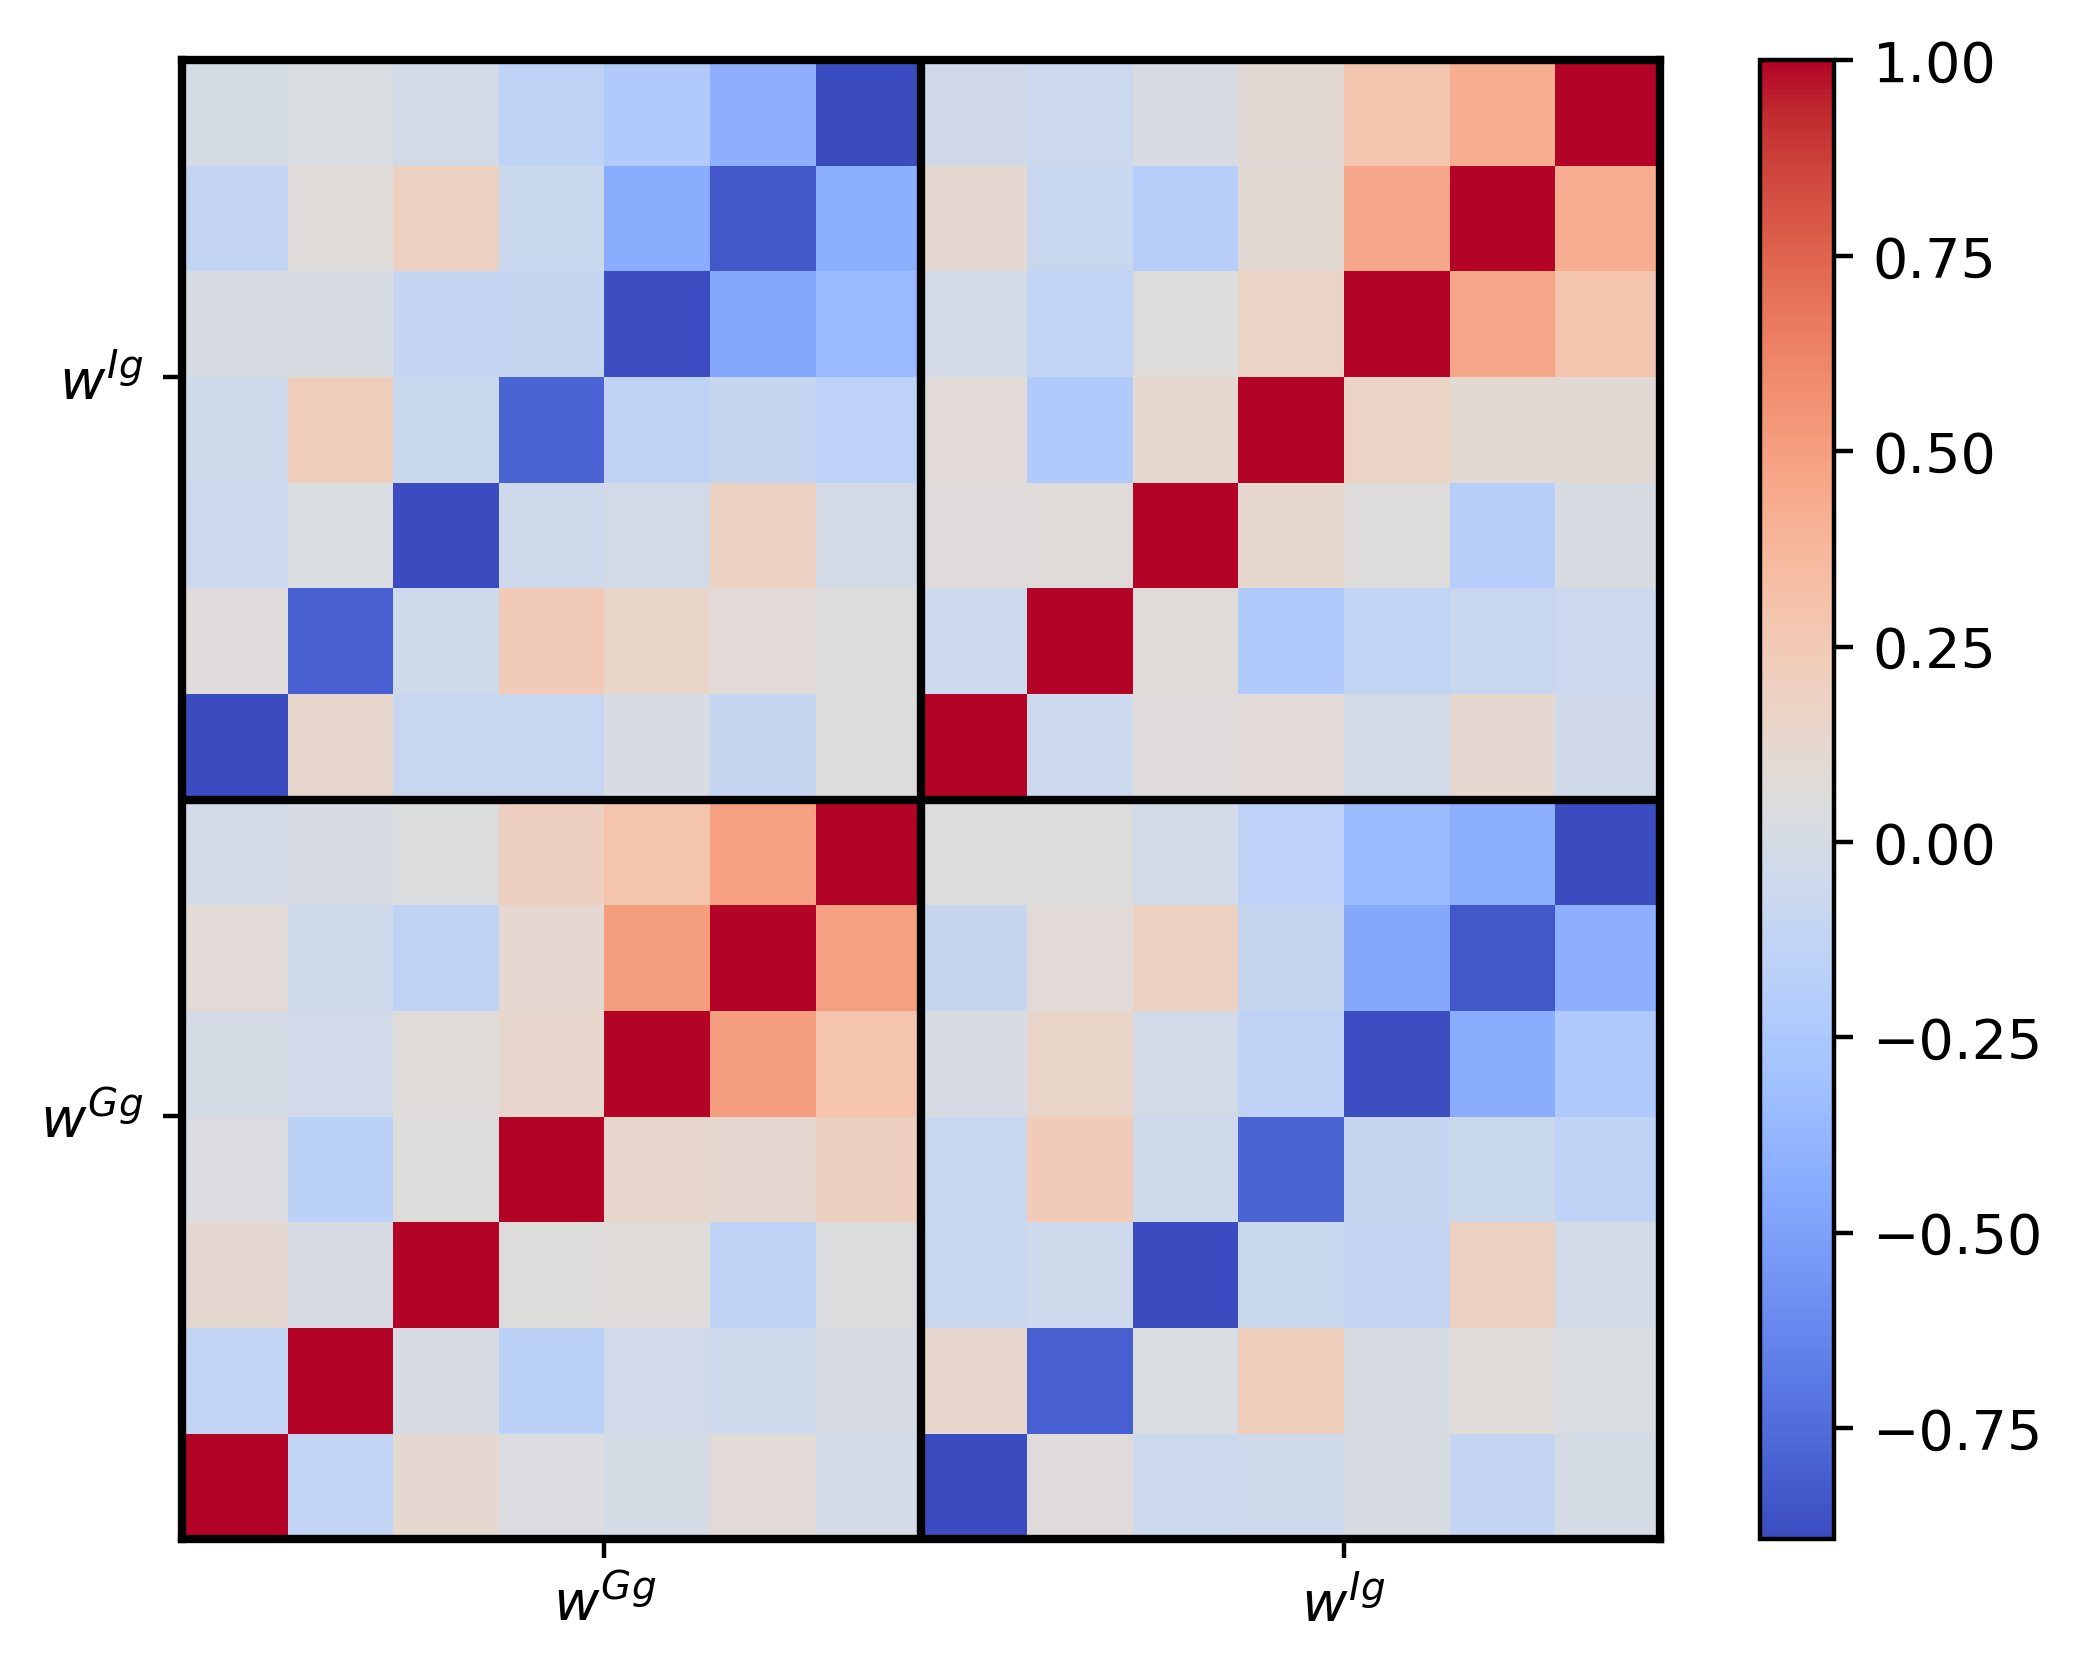

In [56]:
plt.figure(dpi=400)
plt.imshow(wGg_Ig_SC_X_cov/np.sqrt(np.outer(diag_vals, diag_vals)), cmap='coolwarm', origin='lower')
plt.xticks([3.5, 10.5], [r'$w^{Gg}$', r'$w^{Ig}$'])
plt.yticks([3.5, 10.5], [r'$w^{Gg}$', r'$w^{Ig}$'])
plt.axhline(6.5, c='k', lw=1.5)
plt.axvline(6.5, c='k', lw=1.5)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
plt.colorbar()

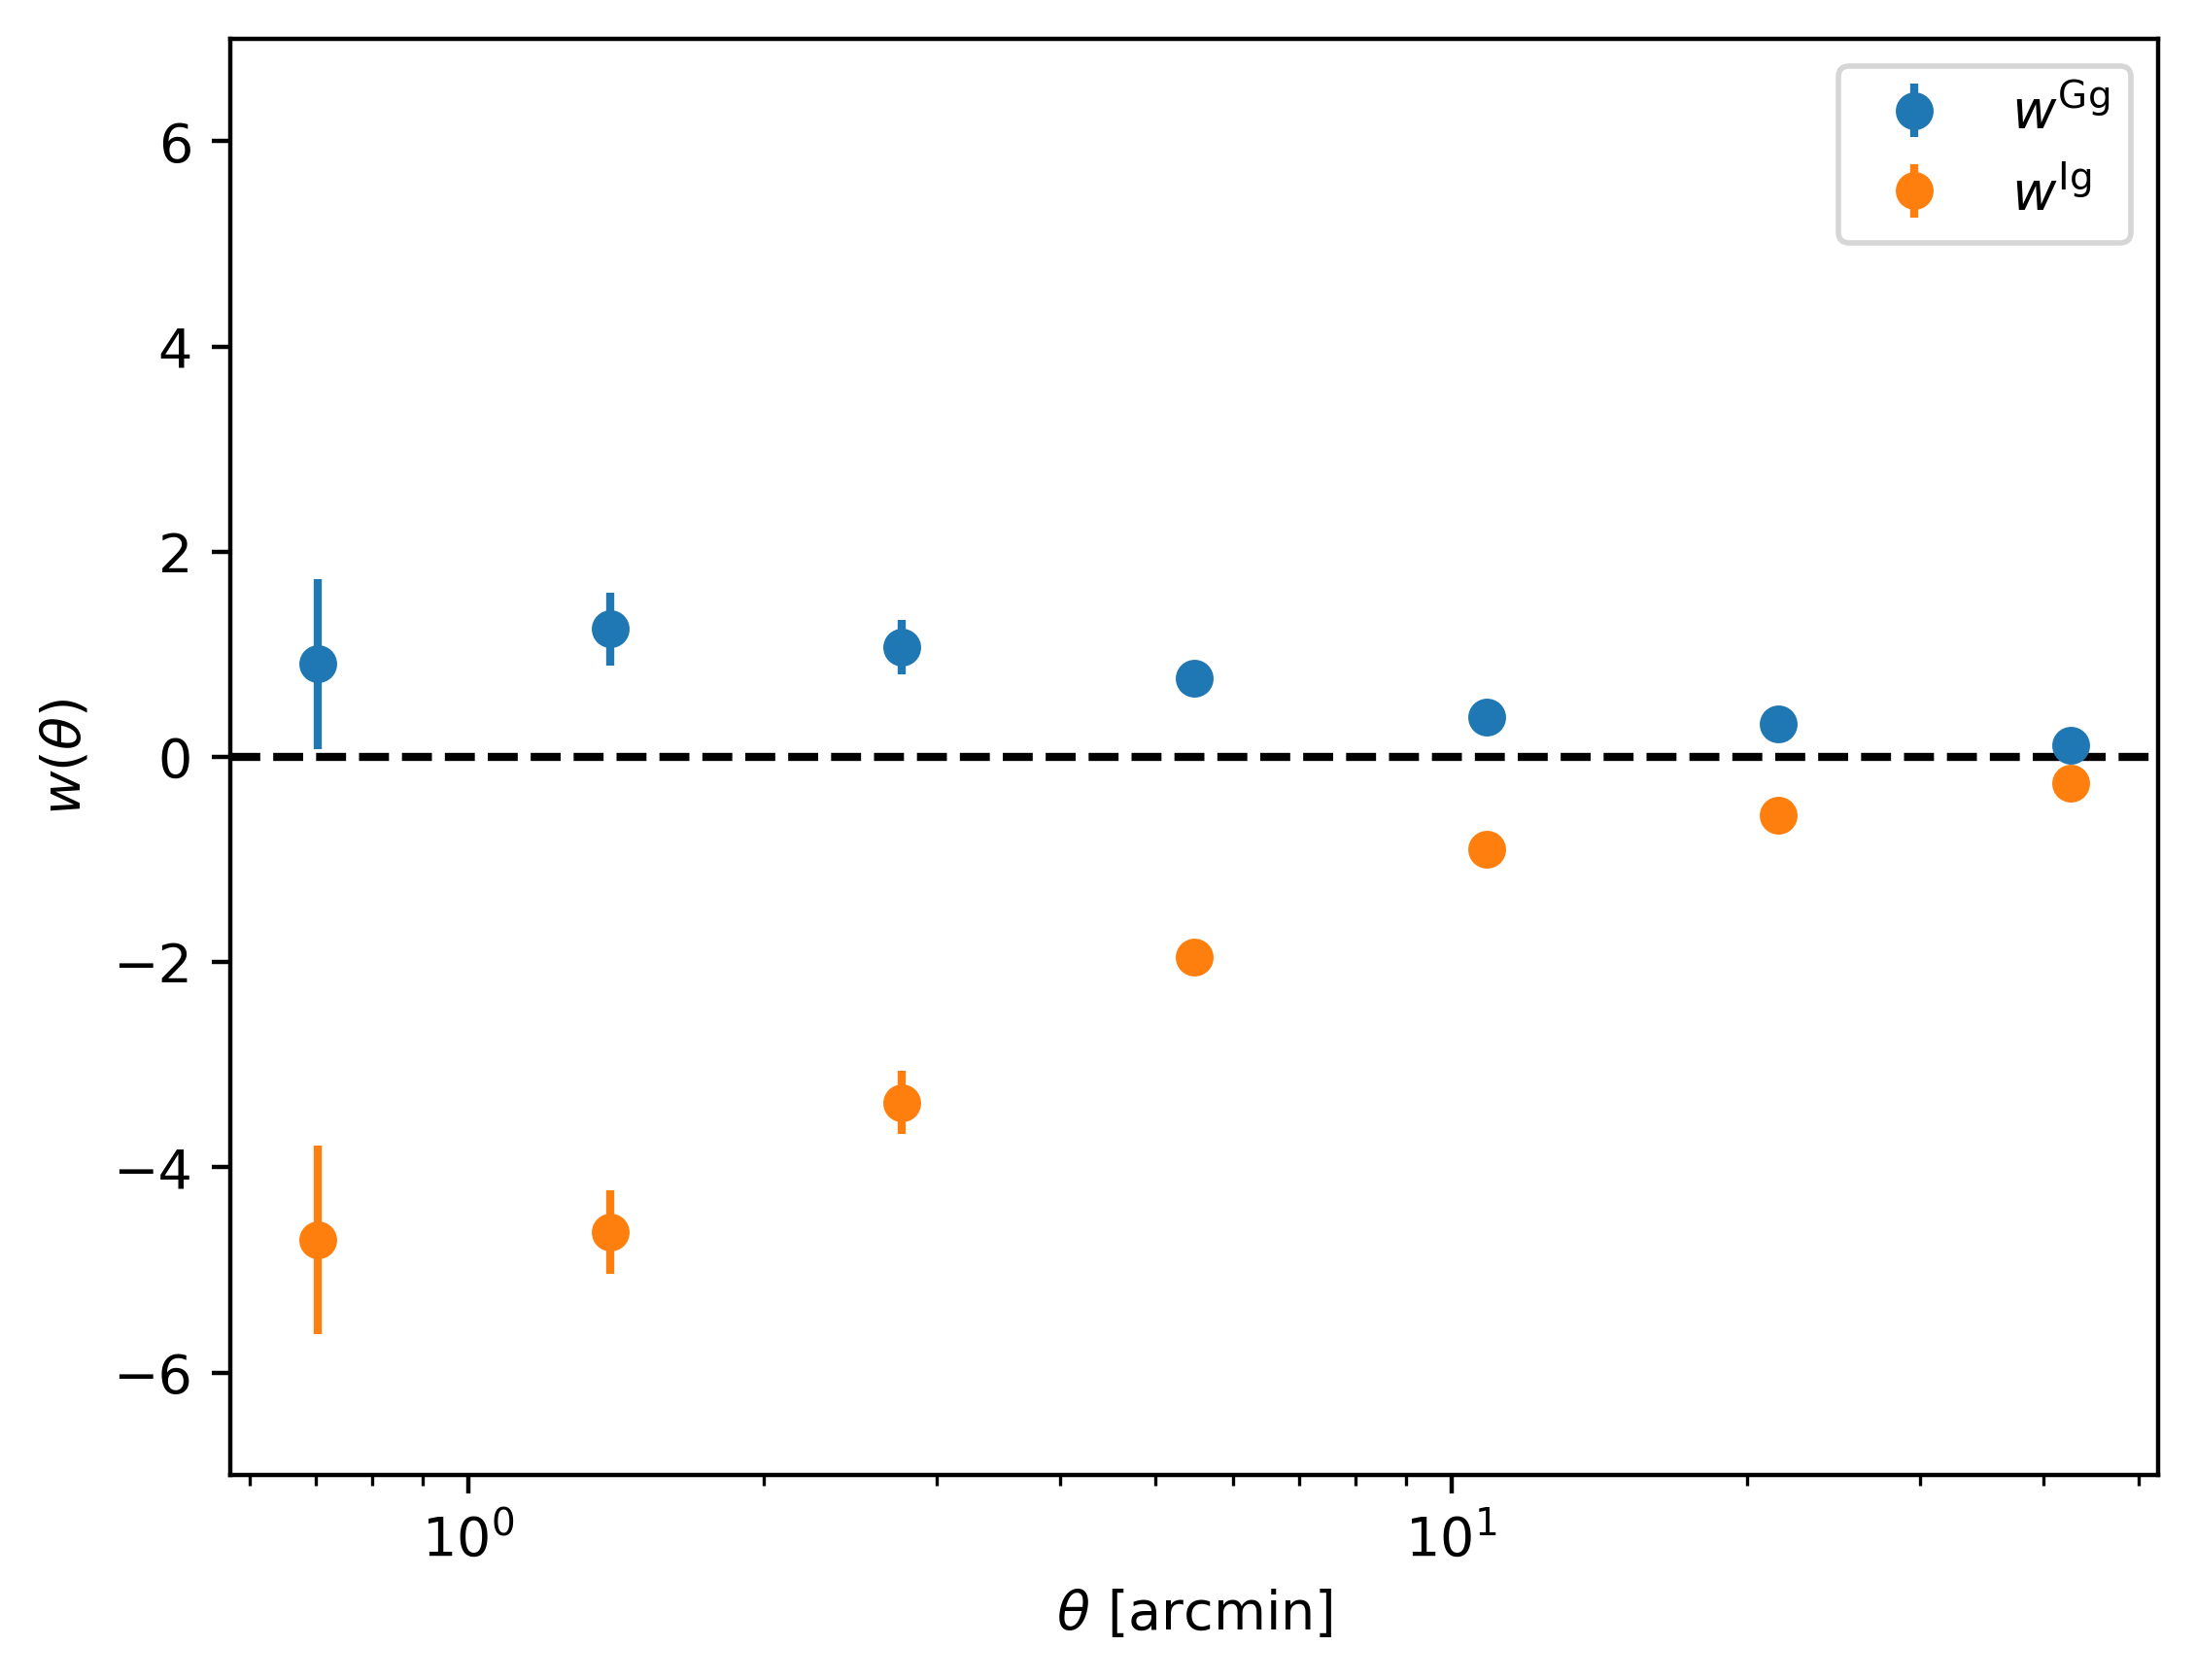

In [57]:
plt.figure(dpi=400)
plt.errorbar(theta_bin, wGg_SC*1e4, np.sqrt(np.diag(wGg_Ig_SC_X_cov)[:7])*1e4, fmt='o', label=r'$w^{\rm Gg}$')
plt.errorbar(theta_bin, wIg_SC*1e4, np.sqrt(np.diag(wGg_Ig_SC_X_cov)[7:])*1e4, fmt='o', label=r'$w^{\rm Ig}$')
plt.legend()
plt.axhline(0, c='k', ls='--')
plt.ylim(-7,7)
plt.xlabel(r'$\theta~[\rm arcmin]$')
plt.ylabel(r'$w(\theta)$')
plt.semilogx();

### Model fitting

In [58]:
C_GG = ccl.angular_cl(cosmo=cosmo_ccl, tracer1=wl, tracer2=wl, ell=ell)

In [59]:
w_Gg_model = ccl.correlation(cosmo=cosmo_ccl, ell=ell, C_ell=C_Gg, theta=theta_bin_deg, type='NG')
w_Ig_model = ccl.correlation(cosmo=cosmo_ccl, ell=ell, C_ell=C_Ig, theta=theta_bin_deg, type='NG')
w_Gk_model = ccl.correlation(cosmo=cosmo_ccl, ell=ell, C_ell=C_GG, theta=theta_bin_deg, type='NG')

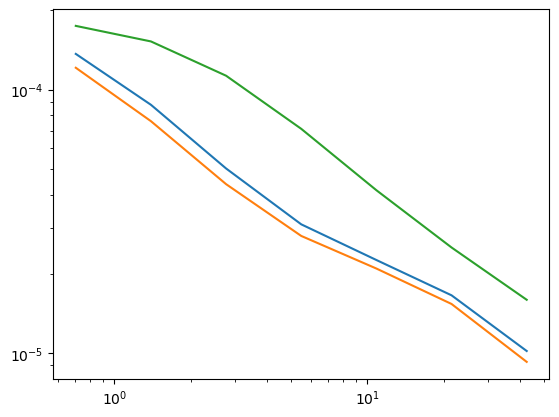

In [60]:
plt.loglog(theta_bin, w_Gg_model)
plt.loglog(theta_bin, -w_Ig_model)
plt.loglog(theta_bin, w_Gk_model)

In [61]:
def cal_w_Gg(bias):
    return bias * w_Gg_model

In [62]:
def cal_w_Ig(bias, A_IA):
    return bias * A_IA * w_Ig_model

In [63]:
def cal_w_mag(gmag):
    return gmag * w_Gk_model

In [64]:
from nautilus import Prior

In [65]:
prior = Prior()
prior.add_parameter('bias', dist=(+1, +3))
prior.add_parameter('A_IA', dist=(-5, +5))
prior.add_parameter('gmag', dist=(-10, +10))

In [66]:
obs = np.append(wGg_SC, wIg_SC)
inv_cov = np.linalg.inv(wGg_Ig_SC_X_cov)

In [67]:
# def likelihood(param_dict):
#     bias = param_dict['bias']
#     A_IA = param_dict['A_IA']
#     gmag = param_dict['gmag']
#     w_Gg = cal_w_Gg(bias)
#     w_Ig = cal_w_Ig(bias, A_IA)
#     w_mag = cal_w_mag(gmag)
#     data_vec = np.concatenate([w_Gg, w_Ig+w_mag])
#     chi2 = (data_vec - obs) @ inv_cov @ (data_vec - obs)
#     return -chi2

In [68]:
# def likelihood(param_dict):
#     bias = param_dict['bias']
#     A_IA = param_dict['A_IA']
#     w_Gg = cal_w_Gg(bias)
#     w_Ig = cal_w_Ig(bias, A_IA)
#     w_mag = cal_w_mag(0)
#     data_vec = np.concatenate([w_Gg, w_Ig+w_mag])
#     chi2 = (data_vec - obs) @ inv_cov @ (data_vec - obs)
#     return -chi2

In [69]:
''' --- drop the last two points '''
n = wGg_SC.shape[0]
obs_cut = np.append(wGg_SC[:-2], wIg_SC[:-2])
idx1 = np.arange(0, 5)          # stat1 保留 1,2,...,6
idx2 = n + np.arange(0, 5)      # stat2 保留 8,9,...,13
idx = np.concatenate([idx1, idx2])

cov_cut = wGg_Ig_SC_X_cov[np.ix_(idx, idx)]
inv_cov_cut = np.linalg.inv(cov_cut)
print(obs_cut.shape, cov_cut.shape)

def likelihood(param_dict):
    bias = param_dict['bias']
    A_IA = param_dict['A_IA']
    gmag = param_dict['gmag']
    w_Gg = cal_w_Gg(bias)
    w_Ig = cal_w_Ig(bias, A_IA)
    w_mag = cal_w_mag(gmag)
    data_vec = np.concatenate([w_Gg[:-2], (w_Ig+w_mag)[:-2]])
    chi2 = (data_vec - obs_cut) @ inv_cov_cut @ (data_vec - obs_cut)
    return -chi2

(10,) (10, 10)


In [70]:
# ''' --- drop first point and the last two points '''
# n = wGg_SC.shape[0]
# obs_cut = np.append(wGg_SC[1:-2], wIg_SC[1:-2])
# idx1 = np.arange(1, 5)          # stat1 保留 1,2,...,6
# idx2 = n + np.arange(1, 5)      # stat2 保留 8,9,...,13
# idx = np.concatenate([idx1, idx2])

# cov_cut = wGg_Ig_SC_X_cov[np.ix_(idx, idx)]
# inv_cov_cut = np.linalg.inv(cov_cut)
# print(obs_cut.shape, cov_cut.shape)

# def likelihood(param_dict):
#     bias = param_dict['bias']
#     A_IA = param_dict['A_IA']
#     gmag = param_dict['gmag']
#     w_Gg = cal_w_Gg(bias)
#     w_Ig = cal_w_Ig(bias, A_IA)
#     w_mag = cal_w_mag(gmag)
#     data_vec = np.concatenate([w_Gg[1:-2], (w_Ig+w_mag)[1:-2]])
#     chi2 = (data_vec - obs_cut) @ inv_cov_cut @ (data_vec - obs_cut)
#     return -chi2

In [71]:
from nautilus import Sampler

In [72]:
sampler = Sampler(prior, likelihood, n_live=1000)

In [73]:
sampler.run(verbose=True)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 19     | 1        | 4        | 23800    | N/A    | 10051 | -47.61   


True

In [74]:
import corner

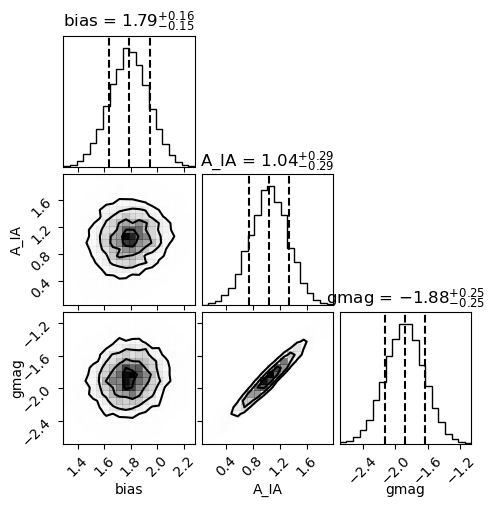

In [75]:
points, log_w, log_l = sampler.posterior()
fig = plt.figure(figsize=(5,5),dpi=100)
corner.corner(
    points, weights=np.exp(log_w), bins=20, labels=prior.keys,
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)),quantiles=[0.16, 0.5, 0.85],show_titles=True,
    fig=fig
);

In [76]:
best_fits = np.median(points, axis=0)
best_fits

array([ 1.79537278,  1.030917  , -1.88281554])

In [77]:
wGg_bestfit = cal_w_Gg(best_fits[0])
wIg_bestfit = cal_w_Ig(best_fits[0], best_fits[1])
wmag_bestfit = cal_w_mag(best_fits[2])

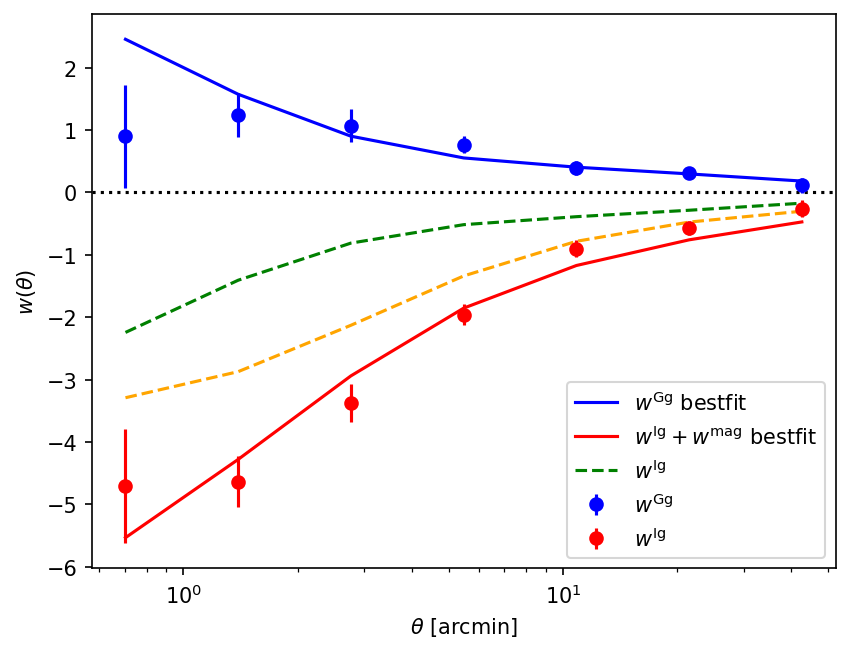

In [78]:
plt.figure(dpi=150)
plt.semilogx(theta_bin, wGg_bestfit*1e4, c='b', label=r'$w^{\rm Gg}$'+' bestfit')
plt.semilogx(theta_bin, wIg_bestfit*1e4+wmag_bestfit*1e4, c='r', label=r'$w^{\rm Ig}+w^{\rm mag}$'+' bestfit')
plt.semilogx(theta_bin, wIg_bestfit*1e4, c='g', ls='--', label=r'$w^{\rm Ig}$')
plt.semilogx(theta_bin, wmag_bestfit*1e4, c='orange', ls='--')
# plt.semilogx(theta_bin, wmag_bestfit*1e4)
plt.errorbar(theta_bin, wGg_SC*1e4, np.sqrt(np.diag(wGg_Ig_SC_X_cov)[:7])*1e4, fmt='o', label=r'$w^{\rm Gg}$', color='b')
plt.errorbar(theta_bin, wIg_SC*1e4, np.sqrt(np.diag(wGg_Ig_SC_X_cov)[7:])*1e4, fmt='o', label=r'$w^{\rm Ig}$', color='r')
plt.axhline(0, c='k', ls=':')
plt.xlabel(r'$\theta~[\rm arcmin]$')
plt.ylabel(r'$w(\theta)$')
plt.legend();

In [79]:
# np.savez(f"results/samples/{catname}_samples.npz", points=points, weights=np.exp(log_w), loglike=log_l)